# Análisis de ventas Amazon — versión revisada

**Cambios respecto a la versión anterior**
- Ingresos **netos** (Delivered + Shipped) separados de los brutos.
- Contrastes estadísticos en método de pago, descuentos, vendedores y estacionalidad.
- Modelos comparados contra un baseline y con el *target leakage* controlado.
- Estacionalidad normalizada por días del mes (unidades/día).
- Previsión evaluada con *backtesting* (rolling origin) frente a modelos ingenuos.
- Churn con **fecha de corte**: variables del pasado, comportamiento del futuro.
- Cross-sell a nivel de cliente (cada pedido tiene un único producto).
- Coste de fallos logísticos = envío + ingreso en riesgo (sin impuestos).
- La **última celda** genera un resumen automático con los resultados para redactar las conclusiones.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.multitest import multipletests
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (mean_absolute_error, r2_score, roc_auc_score,
                             average_precision_score, classification_report)
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
ALFA = 0.05   # nivel de significación

ModuleNotFoundError: No module named 'matplotlib.backends.registry'

## 0. Carga y definiciones de negocio

In [ ]:
df = pd.read_csv('Amazon sales.csv')

# Country es inconsistente con City/State (p. ej. Washington DC -> India): se descarta
df = df.drop(columns='Country')
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

print('Nulos:', int(df.isna().sum().sum()), '| Duplicados:', int(df.duplicated().sum()))
print(f"Periodo: {df['OrderDate'].min().date()} -> {df['OrderDate'].max().date()} | "
      f"Pedidos: {len(df):,} | Clientes: {df['CustomerID'].nunique():,}")

print('\nDistribución de estados (%):')
print(df['OrderStatus'].value_counts(normalize=True).mul(100).round(2))

# Definiciones de negocio (ajustar si procede)
ESTADOS_FALLIDOS = ['Cancelled', 'Returned']
ESTADOS_NETOS = ['Delivered', 'Shipped']      # Pending se excluye del ingreso realizado

df['Fallo'] = df['OrderStatus'].isin(ESTADOS_FALLIDOS)
df['Devuelto'] = df['OrderStatus'].eq('Returned')
df_neto = df[df['OrderStatus'].isin(ESTADOS_NETOS)].copy()

ingreso_bruto = df['TotalAmount'].sum()
ingreso_neto = df_neto['TotalAmount'].sum()
print(f'\nIngreso bruto: {ingreso_bruto:,.0f} $ | Ingreso neto: {ingreso_neto:,.0f} $ '
      f'({ingreso_neto / ingreso_bruto:.1%} del bruto)')

Nulos: 0 | Duplicados: 0
Periodo: 2020-01-01 -> 2024-12-29 | Pedidos: 100,000 | Clientes: 43,233

Distribución de estados (%):
OrderStatus
Delivered    74.63
Shipped      15.19
Pending       4.10
Returned      3.05
Cancelled     3.03
Name: proportion, dtype: float64

Ingreso bruto: 91,825,648 $ | Ingreso neto: 82,456,306 $ (89.8% del bruto)


## 1. Devoluciones según método de pago

                  Tasa_devolucion_%  Devueltos  Pedidos
PaymentMethod                                          
Net Banking                    3.15        313     9927
Amazon Pay                     3.14        472    15017
Credit Card                    3.07       1075    35038
Debit Card                     3.04        609    20024
Cash on Delivery               2.90        143     4928
UPI                            2.90        437    15066

Chi-cuadrado de independencia (método de pago vs devolución): p = 0.800
-> No hay evidencia de que la tasa de devolución dependa del método de pago.


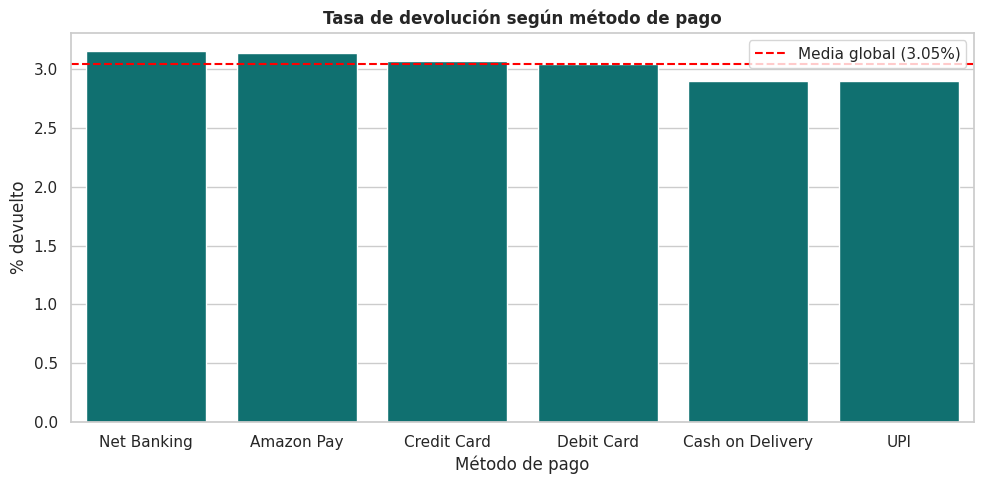

In [ ]:
tasa_dev = df.groupby('PaymentMethod')['Devuelto'].agg(['mean', 'sum', 'count'])
tasa_dev['mean'] *= 100
tasa_dev = tasa_dev.sort_values('mean', ascending=False)
tasa_dev.columns = ['Tasa_devolucion_%', 'Devueltos', 'Pedidos']

chi2, p_pago, _, _ = stats.chi2_contingency(pd.crosstab(df['PaymentMethod'], df['Devuelto']))
media_global = df['Devuelto'].mean() * 100

print(tasa_dev.round(2))
print(f'\nChi-cuadrado de independencia (método de pago vs devolución): p = {p_pago:.3f}')
print('->', 'Hay diferencias significativas entre métodos de pago.' if p_pago < ALFA
      else 'No hay evidencia de que la tasa de devolución dependa del método de pago.')

plt.figure(figsize=(10, 5))
sns.barplot(x=tasa_dev.index, y=tasa_dev['Tasa_devolucion_%'], color='teal')
plt.axhline(media_global, color='red', ls='--', label=f'Media global ({media_global:.2f}%)')
plt.title('Tasa de devolución según método de pago', fontweight='bold')
plt.ylabel('% devuelto'); plt.xlabel('Método de pago'); plt.legend()
plt.tight_layout(); plt.show()

## 2. Impacto de los descuentos

Se mide sobre **unidades por pedido** (comportamiento) e **ingreso neto** (Delivered + Shipped).
Limitación: el dataset solo contiene pedidos realizados, así que no permite medir si el descuento
atrae *más pedidos*; para eso haría falta un test A/B.

          Pedidos  Unidades_medias  Ticket_neto_medio  Uplift_unidades_obs_%  Uplift_necesario_%
Discount                                                                                        
0.00        40246             3.01             986.90                   0.00                0.00
0.05        19889             3.00             944.08                  -0.36                5.26
0.10        14910             3.00             899.10                  -0.24               11.11
0.15        10041             3.00             841.63                  -0.23               17.65
0.20         7939             2.99             793.40                  -0.41               25.00
0.25         4986             3.00             744.03                  -0.32               33.33
0.30         1989             3.05             725.92                   1.41               42.86

Kruskal-Wallis (Quantity según nivel de descuento): p = 0.759
Spearman Discount-Quantity: rho = -0.002 (p = 0.633)
Ticket neto

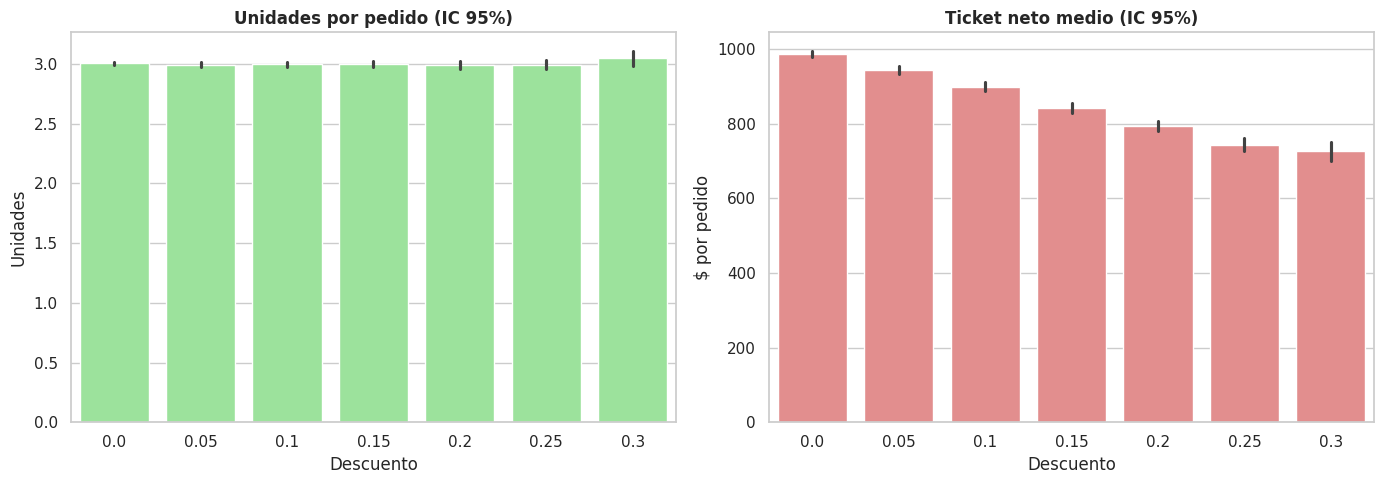

In [ ]:
por_desc = df.groupby('Discount').agg(Pedidos=('OrderID', 'count'),
                                      Unidades_medias=('Quantity', 'mean'))
por_desc['Ticket_neto_medio'] = df_neto.groupby('Discount')['TotalAmount'].mean()
por_desc['Uplift_unidades_obs_%'] = (por_desc['Unidades_medias'] / por_desc['Unidades_medias'].iloc[0] - 1) * 100
# Aumento de unidades necesario solo para no perder ingreso (sin contar margen)
por_desc['Uplift_necesario_%'] = (1 / (1 - por_desc.index.to_series()) - 1) * 100
print(por_desc.round(2).to_string())

_, p_kw = stats.kruskal(*[g['Quantity'].values for _, g in df.groupby('Discount')])
rho, p_rho = stats.spearmanr(df['Discount'], df['Quantity'])
caida_ticket = (por_desc['Ticket_neto_medio'].iloc[-1] / por_desc['Ticket_neto_medio'].iloc[0] - 1) * 100
uplift_obs = por_desc['Uplift_unidades_obs_%'].iloc[-1]
uplift_nec = por_desc['Uplift_necesario_%'].iloc[-1]

print(f'\nKruskal-Wallis (Quantity según nivel de descuento): p = {p_kw:.3f}')
print(f'Spearman Discount-Quantity: rho = {rho:.3f} (p = {p_rho:.3f})')
print(f'Ticket neto con el descuento máximo vs. sin descuento: {caida_ticket:.1f}%')
print(f'Uplift de unidades observado: {uplift_obs:.1f}% | necesario para compensar: {uplift_nec:.1f}%')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x='Discount', y='Quantity', errorbar=('se', 1.96), color='lightgreen', ax=ax[0])
ax[0].set_title('Unidades por pedido (IC 95%)', fontweight='bold')
ax[0].set_xlabel('Descuento'); ax[0].set_ylabel('Unidades')
sns.barplot(data=df_neto, x='Discount', y='TotalAmount', errorbar=('se', 1.96), color='lightcoral', ax=ax[1])
ax[1].set_title('Ticket neto medio (IC 95%)', fontweight='bold')
ax[1].set_xlabel('Descuento'); ax[1].set_ylabel('$ por pedido')
plt.tight_layout(); plt.show()

### 2.1 ¿Se puede predecir la cantidad? (con control de *leakage*)

`TotalAmount` y `Tax` se calculan a partir de `Quantity`, y `ShippingCost` no se conoce al decidir la cantidad:
se excluyen. Se compara contra un **baseline** (predecir la media): un R² ≈ 0 significa que no hay señal.
Importancia de variables **no** equivale a efecto causal y no se interpreta si el modelo no supera al baseline.

In [ ]:
cols_id = ['OrderID', 'SellerID', 'CustomerID', 'OrderDate', 'CustomerName', 'ProductID',
           'ProductName', 'Brand', 'City', 'State']
base = df.drop(columns=cols_id + ['Fallo', 'Devuelto', 'OrderStatus'])
base['Mes'] = df['OrderDate'].dt.month
base = pd.get_dummies(base, columns=['PaymentMethod', 'Category', 'Mes'], drop_first=True)

y_q = base['Quantity']
X_leak = base.drop(columns='Quantity')                                    # con leakage (demostración)
X_ok = X_leak.drop(columns=['TotalAmount', 'Tax', 'ShippingCost'])       # solo variables conocidas antes de comprar

idx_tr, idx_te = train_test_split(base.index, test_size=0.2, random_state=42)

def evaluar(modelo, X, nombre):
    modelo.fit(X.loc[idx_tr], y_q.loc[idx_tr])
    pred = modelo.predict(X.loc[idx_te])
    r2 = r2_score(y_q.loc[idx_te], pred)
    mae = mean_absolute_error(y_q.loc[idx_te], pred)
    print(f'{nombre:<40} R² = {r2:7.4f} | MAE = {mae:.3f}')
    return r2

r2_base = evaluar(DummyRegressor(strategy='mean'), X_ok, 'Baseline (predecir la media)')
r2_leak = evaluar(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), X_leak, 'RF CON leakage (Tax, TotalAmount)')
r2_ok = evaluar(RandomForestRegressor(n_estimators=100, min_samples_leaf=20, random_state=42, n_jobs=-1), X_ok, 'RF sin leakage')

print('\n->', 'Las variables disponibles antes de comprar NO predicen la cantidad mejor que la media.'
      if r2_ok < r2_base + 0.01 else 'Existe señal predictiva sobre la cantidad; revisar variables relevantes.')

# Mismo test por categoría (modelo específico de cada una)
cat_cols = [c for c in X_ok.columns if c.startswith('Category_')]
X_cat = X_ok.drop(columns=cat_cols)
filas = []
for cat, sub in df.groupby('Category'):
    tr, te = train_test_split(sub.index, test_size=0.2, random_state=42)
    m = RandomForestRegressor(n_estimators=100, min_samples_leaf=20, random_state=42, n_jobs=-1)
    m.fit(X_cat.loc[tr], y_q.loc[tr])
    filas.append({'Categoria': cat, 'Filas': len(sub), 'R2_test': r2_score(y_q.loc[te], m.predict(X_cat.loc[te]))})
r2_cat = pd.DataFrame(filas).sort_values('R2_test', ascending=False)
print('\nR² por categoría:')
print(r2_cat.round(4).to_string(index=False))

Baseline (predecir la media)             R² = -0.0000 | MAE = 1.200


RF CON leakage (Tax, TotalAmount)        R² =  0.9973 | MAE = 0.023


RF sin leakage                           R² = -0.0146 | MAE = 1.226

-> Las variables disponibles antes de comprar NO predicen la cantidad mejor que la media.



R² por categoría:
        Categoria  Filas  R2_test
   Home & Kitchen  16610  -0.0147
Sports & Outdoors  16804  -0.0164
      Electronics  16853  -0.0166
         Clothing  16439  -0.0180
     Toys & Games  16542  -0.0213
            Books  16752  -0.0282


## 3. Segmentación de clientes (RFM)

Calculada sobre pedidos **netos**. Se cuantifica el peso de cada segmento en clientes **e ingresos**.

                                 Clientes    Ingresos  Gasto_medio_cliente  %_Clientes  %_Ingresos
Segmento                                                                                          
Activos recurrentes                 18337  43742680.4               2385.5        43.9        53.0
VIP                                  2722  12326439.1               4528.4         6.5        14.9
Alto valor inactivo (win-back)       2722   9135042.2               3356.0         6.5        11.1
Perdidos (1 compra, hace mucho)      7705   6302099.8                817.9        18.5         7.6
Recurrentes en riesgo                3478   4698584.8               1350.9         8.3         5.7
Ocasionales (resto)                  4095   3832375.9                935.9         9.8         4.6
Nuevos (1ª compra reciente)          2679   2419084.0                903.0         6.4         2.9


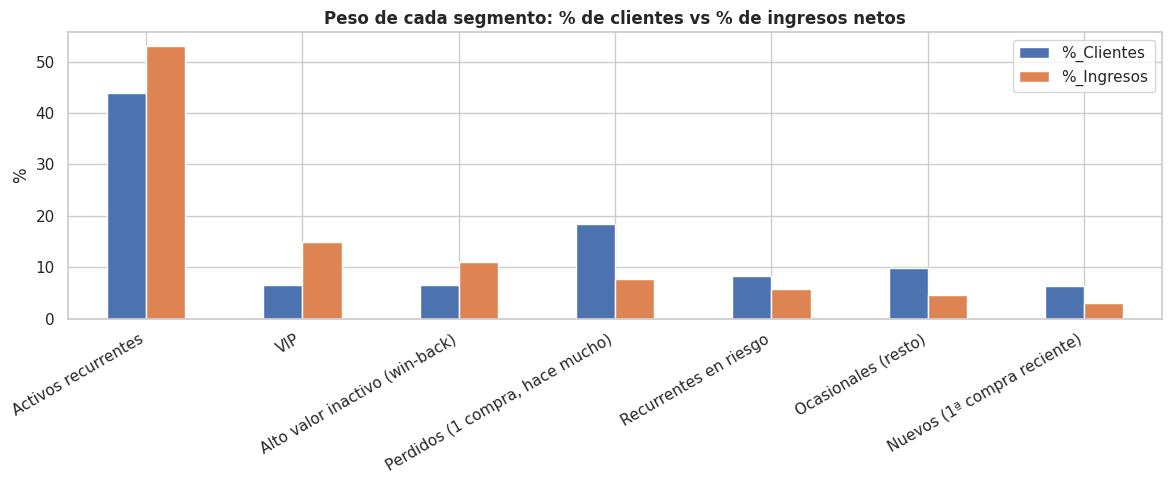

In [ ]:
fecha_ref = df['OrderDate'].max() + pd.Timedelta(days=1)

rfm = df_neto.groupby('CustomerID').agg(
    Recencia=('OrderDate', lambda x: (fecha_ref - x.max()).days),
    Frecuencia=('OrderID', 'count'),
    Valor=('TotalAmount', 'sum')).reset_index()

rfm['R'] = pd.qcut(rfm['Recencia'], q=3, labels=[3, 2, 1]).astype(int)          # 3 = compró hace poco
rfm['F'] = pd.cut(rfm['Frecuencia'], bins=[0, 1, 3, np.inf], labels=[1, 2, 3]).astype(int)   # 1 | 2-3 | >3 pedidos
rfm['M'] = pd.qcut(rfm['Valor'], q=3, labels=[1, 2, 3]).astype(int)

condiciones = [
    (rfm.R == 3) & (rfm.F == 3) & (rfm.M == 3),
    (rfm.R == 1) & (rfm.M == 3),
    (rfm.R == 1) & (rfm.F >= 2),
    (rfm.R >= 2) & (rfm.F >= 2),
    (rfm.R == 3) & (rfm.F == 1),
    (rfm.R == 1) & (rfm.F == 1),
]
nombres = ['VIP', 'Alto valor inactivo (win-back)', 'Recurrentes en riesgo',
           'Activos recurrentes', 'Nuevos (1ª compra reciente)', 'Perdidos (1 compra, hace mucho)']
rfm['Segmento'] = np.select(condiciones, nombres, default='Ocasionales (resto)')

res_rfm = rfm.groupby('Segmento').agg(Clientes=('CustomerID', 'count'),
                                      Ingresos=('Valor', 'sum'),
                                      Gasto_medio_cliente=('Valor', 'mean'))
res_rfm['%_Clientes'] = res_rfm['Clientes'] / res_rfm['Clientes'].sum() * 100
res_rfm['%_Ingresos'] = res_rfm['Ingresos'] / res_rfm['Ingresos'].sum() * 100
res_rfm = res_rfm.sort_values('Ingresos', ascending=False)
print(res_rfm.round(1).to_string())

res_rfm[['%_Clientes', '%_Ingresos']].plot(kind='bar', figsize=(12, 5))
plt.title('Peso de cada segmento: % de clientes vs % de ingresos netos', fontweight='bold')
plt.ylabel('%'); plt.xlabel(''); plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

## 4. Fallos logísticos (cancelaciones + devoluciones)

1. ¿Hay diferencias **reales** entre vendedores o solo azar? (chi-cuadrado + test binomial por vendedor con corrección FDR).
2. Coste real de los fallos: **envío perdido + ingreso en riesgo**. El impuesto (`Tax`) no se cuenta como coste, ya que se reembolsa en una cancelación/devolución.

Tasa global de fallo (cancelados + devueltos): 6.08%
Chi-cuadrado de homogeneidad entre 1089 vendedores: p = 0.637
Vendedores significativamente peores que la media (FDR 5%): 0

Top 10 por tasa bruta (con intervalo de confianza):
           Ventas  Fallos  Tasa_%  IC95_inf_%  IC95_sup_%  p_ajustado
SellerID                                                             
SELL01533      50       9  18.000       9.770      30.796         1.0
SELL01444      52       9  17.308       9.382      29.731         1.0
SELL01578      53       9  16.981       9.200      29.225         1.0
SELL00530      54       9  16.667       9.024      28.737         1.0
SELL01066      57       9  15.789       8.536      27.363         1.0
SELL01979      51       8  15.686       8.169      28.010         1.0
SELL01742      53       8  15.094       7.852      27.054         1.0
SELL00266      54       8  14.815       7.703      26.600         1.0
SELL01014      54       8  14.815       7.703      26.600         1.0


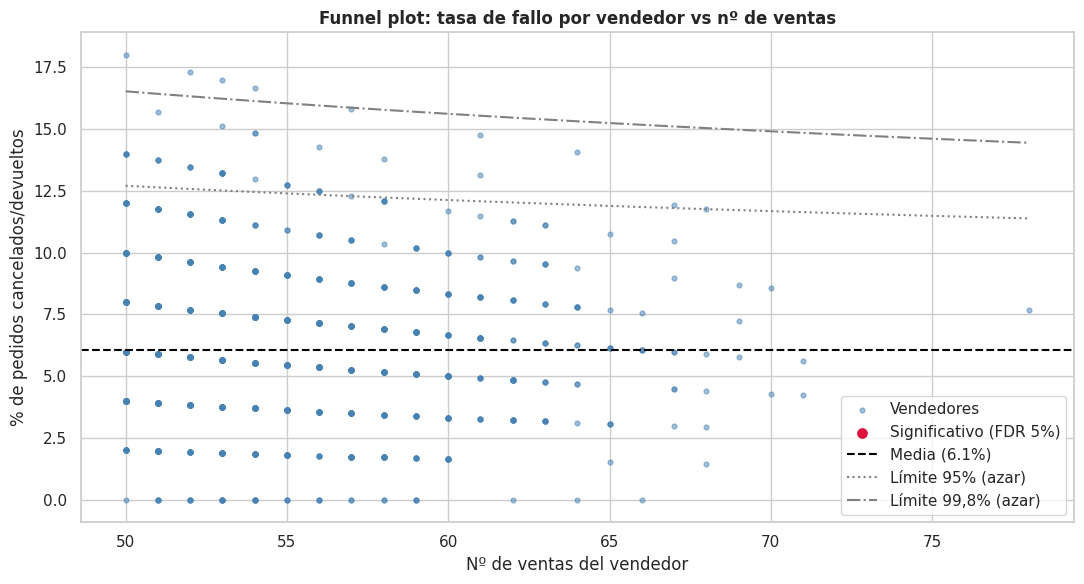

In [ ]:
tasa_global = df['Fallo'].mean()
print(f'Tasa global de fallo (cancelados + devueltos): {tasa_global:.2%}')

vend = df.groupby('SellerID').agg(Ventas=('OrderID', 'count'), Fallos=('Fallo', 'sum'))
vend = vend[vend['Ventas'] >= 50].copy()
vend['Tasa_%'] = vend['Fallos'] / vend['Ventas'] * 100

# (a) Heterogeneidad global entre vendedores
tabla_v = np.column_stack([vend['Fallos'], vend['Ventas'] - vend['Fallos']])
_, p_vend, _, _ = stats.chi2_contingency(tabla_v)
print(f'Chi-cuadrado de homogeneidad entre {len(vend)} vendedores: p = {p_vend:.3f}')

# (b) Test binomial unilateral por vendedor + corrección por comparaciones múltiples (Benjamini-Hochberg)
vend['p'] = [stats.binomtest(int(f), int(n), tasa_global, alternative='greater').pvalue
             for f, n in zip(vend['Fallos'], vend['Ventas'])]
vend['p_ajustado'] = multipletests(vend['p'], method='fdr_bh')[1]
vend['Significativo'] = vend['p_ajustado'] < ALFA
n_signif = int(vend['Significativo'].sum())

lo, hi = proportion_confint(vend['Fallos'], vend['Ventas'], method='wilson')
vend['IC95_inf_%'] = lo * 100
vend['IC95_sup_%'] = hi * 100

print(f'Vendedores significativamente peores que la media (FDR {ALFA:.0%}): {n_signif}')
print('\nTop 10 por tasa bruta (con intervalo de confianza):')
print(vend.sort_values('Tasa_%', ascending=False).head(10)[
    ['Ventas', 'Fallos', 'Tasa_%', 'IC95_inf_%', 'IC95_sup_%', 'p_ajustado']].round(3).to_string())

# Funnel plot: qué dispersión produciría el azar
n_rng = np.arange(vend['Ventas'].min(), vend['Ventas'].max() + 1)
se = np.sqrt(tasa_global * (1 - tasa_global) / n_rng)
plt.figure(figsize=(11, 6))
plt.scatter(vend['Ventas'], vend['Tasa_%'], s=12, alpha=0.5, color='steelblue', label='Vendedores')
sig_v = vend[vend['Significativo']]
plt.scatter(sig_v['Ventas'], sig_v['Tasa_%'], s=45, color='crimson', label='Significativo (FDR 5%)')
plt.axhline(tasa_global * 100, color='black', ls='--', label=f'Media ({tasa_global:.1%})')
plt.plot(n_rng, (tasa_global + 1.96 * se) * 100, color='gray', ls=':', label='Límite 95% (azar)')
plt.plot(n_rng, (tasa_global + 3.09 * se) * 100, color='gray', ls='-.', label='Límite 99,8% (azar)')
plt.title('Funnel plot: tasa de fallo por vendedor vs nº de ventas', fontweight='bold')
plt.xlabel('Nº de ventas del vendedor'); plt.ylabel('% de pedidos cancelados/devueltos')
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# Coste de los fallos: envío + ingreso en riesgo (sin impuestos)
fallidos = df[df['Fallo']]
desglose = fallidos.groupby('OrderStatus').agg(Pedidos=('OrderID', 'count'),
                                              Ingreso_en_riesgo=('TotalAmount', 'sum'),
                                              Envio_perdido=('ShippingCost', 'sum'))
print(desglose.round(0))

coste_envio = fallidos['ShippingCost'].sum()
ingreso_riesgo = fallidos['TotalAmount'].sum()
print(f"\nCoste de envío de pedidos fallidos: {coste_envio:,.0f} $ "
      f"({fallidos['ShippingCost'].mean():.2f} $ por pedido; {coste_envio / ingreso_bruto:.2%} del ingreso bruto)")
print(f'Ingreso en riesgo (valor de pedidos fallidos): {ingreso_riesgo:,.0f} $ ({ingreso_riesgo / ingreso_bruto:.1%} del bruto)')

# Impacto de los vendedores significativamente malos (solo el exceso sobre lo esperado)
sig = vend[vend['Significativo']].copy()
if len(sig):
    sig['Fallos_esperados'] = sig['Ventas'] * tasa_global
    sig['Exceso_fallos'] = sig['Fallos'] - sig['Fallos_esperados']
    sig['Ingreso_en_riesgo_exceso'] = sig['Exceso_fallos'] * fallidos['TotalAmount'].mean()
    print('\nVendedores a investigar (ordenados por ingreso en riesgo adicional):')
    print(sig.sort_values('Ingreso_en_riesgo_exceso', ascending=False).head(10)[
        ['Ventas', 'Fallos', 'Tasa_%', 'Exceso_fallos', 'Ingreso_en_riesgo_exceso']].round(1).to_string())
else:
    print('\nNingún vendedor supera lo esperable por azar: no hay base estadística para señalar vendedores concretos.')

             Pedidos  Ingreso_en_riesgo  Envio_perdido
OrderStatus                                           
Cancelled       3028          2851122.0        22412.0
Returned        3049          2780662.0        22653.0

Coste de envío de pedidos fallidos: 45,065 $ (7.42 $ por pedido; 0.05% del ingreso bruto)
Ingreso en riesgo (valor de pedidos fallidos): 5,631,785 $ (6.1% del bruto)

Ningún vendedor supera lo esperable por azar: no hay base estadística para señalar vendedores concretos.


## 5. Estacionalidad

Los meses tienen distinta duración (febrero ≈ 28 días), así que se normaliza **por día**.
Se contrasta si (a) el volumen diario varía por mes y (b) el mix de categorías cambia según el mes.

    Dias  Pedidos  Unidades  Ingreso_neto  Ingreso_neto_dia  Indice_bruto_%  Indice_por_dia_%
1    155     8638     25955     7115091.8           45903.8             3.5               1.6
2    142     7618     22670     6248038.6           44000.3            -9.1              -2.6
3    155     8438     25245     6922089.6           44658.6             0.7              -1.1
4    150     8210     24809     6832590.0           45550.6            -0.6               0.8
5    155     8559     25572     7083196.5           45698.0             3.1               1.2
6    150     8312     25204     6881257.7           45875.1             0.1               1.5
7    155     8437     25283     6976369.0           45008.8             1.5              -0.4
8    155     8668     25953     7062442.5           45564.1             2.8               0.9
9    150     8276     24671     6793833.0           45292.2            -1.1               0.3
10   155     8254     24976     6913557.1           44603.6 

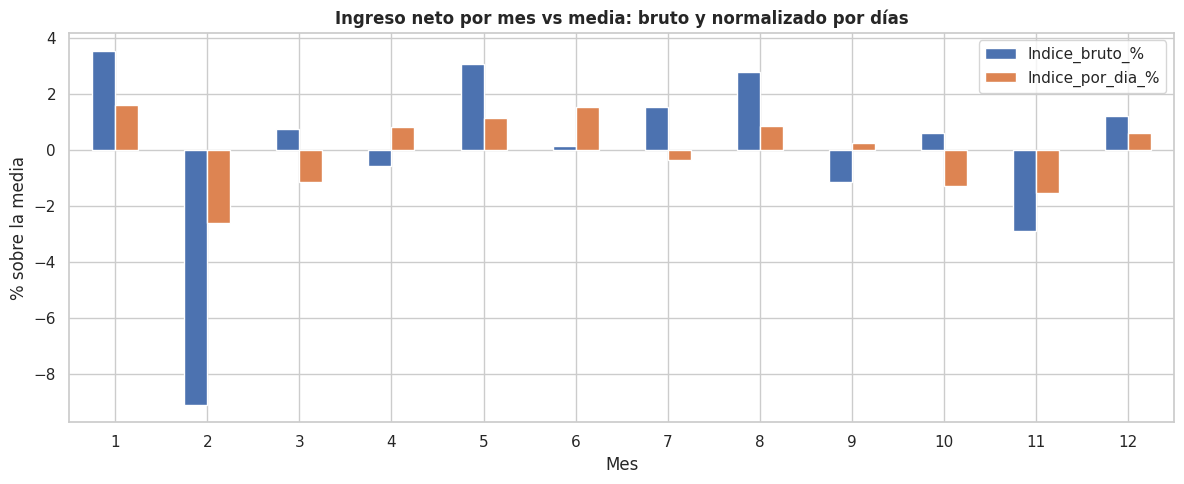


Chi-cuadrado de independencia (mes vs categoría): p = 0.909


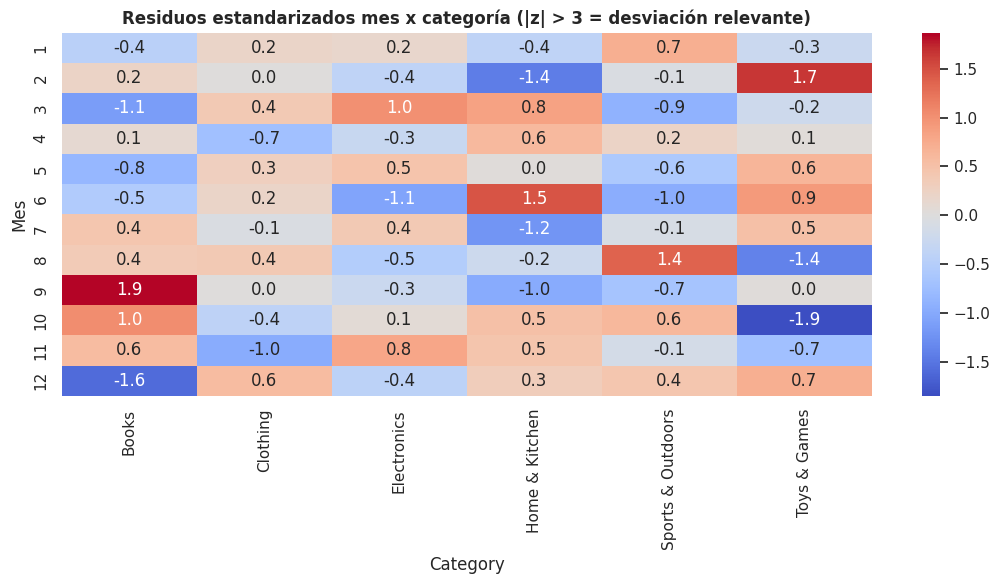

In [ ]:
df['Mes'] = df['OrderDate'].dt.month
dias_mes = pd.Series(pd.date_range(df['OrderDate'].min(), df['OrderDate'].max()).month).value_counts().sort_index()

est = pd.DataFrame({
    'Dias': dias_mes,
    'Pedidos': df.groupby('Mes')['OrderID'].count(),
    'Unidades': df.groupby('Mes')['Quantity'].sum(),
    'Ingreso_neto': df_neto.groupby(df_neto['OrderDate'].dt.month)['TotalAmount'].sum()})
est['Ingreso_neto_dia'] = est['Ingreso_neto'] / est['Dias']
est['Indice_bruto_%'] = (est['Ingreso_neto'] / est['Ingreso_neto'].mean() - 1) * 100
est['Indice_por_dia_%'] = (est['Ingreso_neto_dia'] / est['Ingreso_neto_dia'].mean() - 1) * 100
print(est.round(1).to_string())

# (a) ¿Varían los pedidos por mes más allá de lo que explican los días del mes?
esperado = est['Dias'] / est['Dias'].sum() * est['Pedidos'].sum()
_, p_mes = stats.chisquare(est['Pedidos'], esperado)
rango_estac = est['Indice_por_dia_%'].max() - est['Indice_por_dia_%'].min()
print(f'\nChi-cuadrado (pedidos por mes vs esperado según días): p = {p_mes:.3f}')
print(f'Rango del índice por día entre el mejor y el peor mes: {rango_estac:.1f} puntos')

est[['Indice_bruto_%', 'Indice_por_dia_%']].plot(kind='bar', figsize=(12, 5))
plt.title('Ingreso neto por mes vs media: bruto y normalizado por días', fontweight='bold')
plt.xlabel('Mes'); plt.ylabel('% sobre la media'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

# (b) ¿Cambia el mix de categorías según el mes?
ct = pd.crosstab(df['Mes'], df['Category'])
_, p_cat_mes, _, esp = stats.chi2_contingency(ct)
resid = (ct - esp) / np.sqrt(esp)
print(f'\nChi-cuadrado de independencia (mes vs categoría): p = {p_cat_mes:.3f}')

plt.figure(figsize=(11, 6))
sns.heatmap(resid, annot=True, fmt='.1f', cmap='coolwarm', center=0)
plt.title('Residuos estandarizados mes x categoría (|z| > 3 = desviación relevante)', fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Demanda: tendencia y previsión

- Se trabaja en **unidades por día** (elimina el efecto de la duración del mes; el último mes está incompleto y así no distorsiona).
- La tendencia se cuantifica en % (regresión), no a ojo.
- Los modelos se comparan con **backtesting** (rolling origin, horizonte 3 meses) frente a dos modelos ingenuos.

60 meses | media = 164.4 unidades/día
2020 vs resto -> diferencia de media: p = 0.999 | diferencia de variabilidad: p = 0.077
Tendencia: +0.06% anual (p = 0.806)
           Unidades_por_dia  Var_interanual_%
OrderDate                                    
2020                 164.44               NaN
2021                 163.39             -0.64
2022                 164.71              0.81
2023                 165.96              0.76
2024                 163.70             -1.36


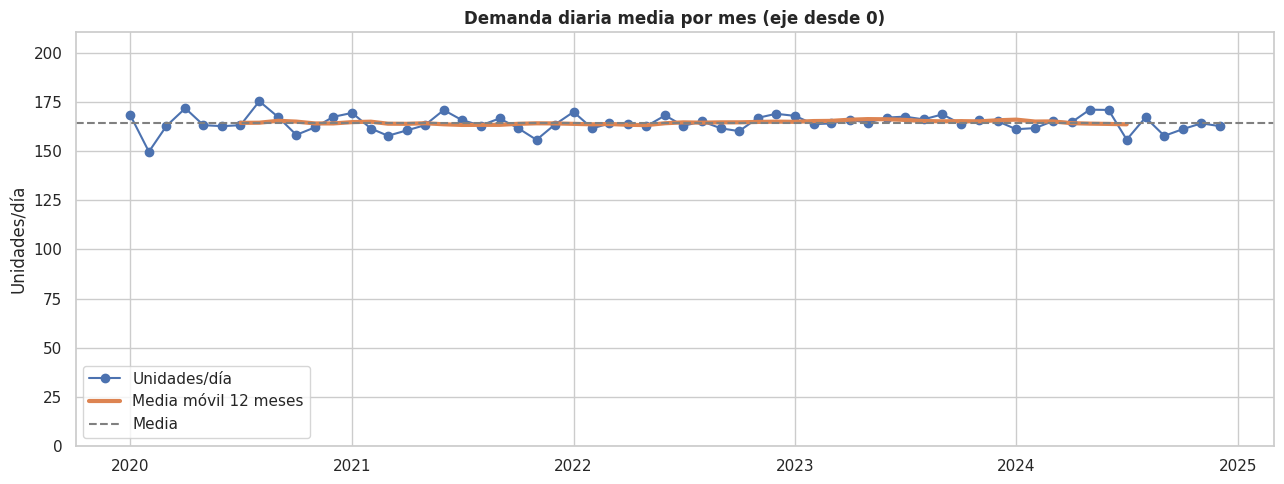

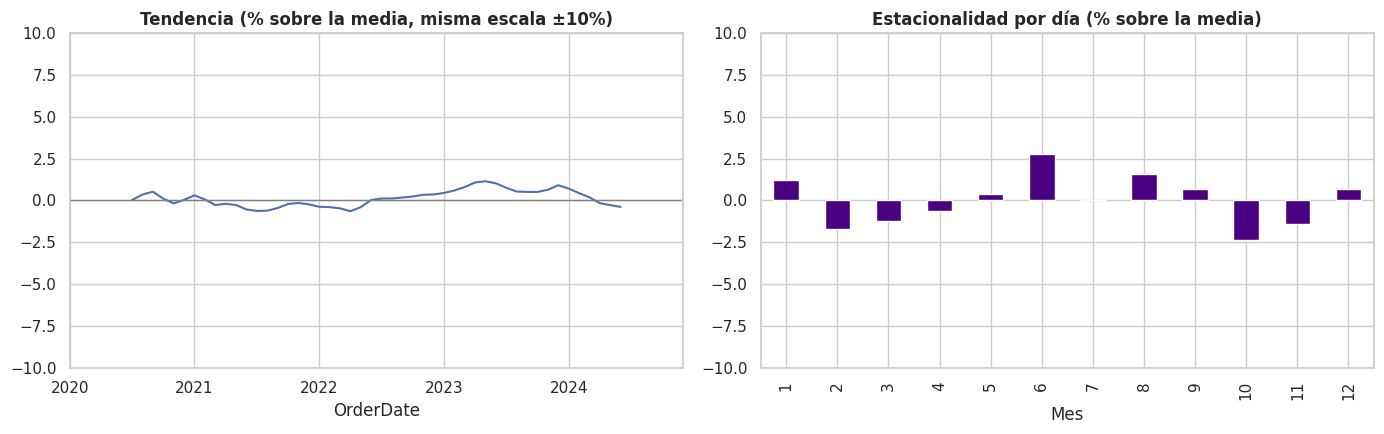

In [ ]:
INICIO_SERIE = '2020-01-01'    # cambiar si se decide excluir un periodo

ventas_diarias = df.groupby('OrderDate')['Quantity'].sum()
mensual = ventas_diarias.resample('ME').sum()
dias_reales = pd.Series(mensual.index.days_in_month, index=mensual.index)
if df['OrderDate'].max() < mensual.index[-1]:                 # último mes incompleto
    dias_reales.iloc[-1] = df['OrderDate'].max().day

serie_dia = (mensual / dias_reales)[lambda s: s.index >= INICIO_SERIE]
serie_dia.name = 'Unidades_por_dia'
print(f'{len(serie_dia)} meses | media = {serie_dia.mean():.1f} unidades/día')

# ¿Es 2020 distinto del resto? (antes se excluía asumiendo un efecto COVID)
a20, resto = serie_dia[serie_dia.index.year == 2020], serie_dia[serie_dia.index.year > 2020]
if len(a20) > 3 and len(resto) > 3:
    _, p_var20 = stats.levene(a20, resto)
    _, p_med20 = stats.ttest_ind(a20, resto, equal_var=False)
    print(f'2020 vs resto -> diferencia de media: p = {p_med20:.3f} | diferencia de variabilidad: p = {p_var20:.3f}')

# Tendencia: regresión lineal sobre unidades/día
lr = stats.linregress(np.arange(len(serie_dia)), serie_dia.values)
pct_anual = lr.slope * 12 / serie_dia.mean() * 100
p_tend = lr.pvalue
print(f'Tendencia: {pct_anual:+.2f}% anual (p = {p_tend:.3f})')

anual = serie_dia.groupby(serie_dia.index.year).mean().to_frame('Unidades_por_dia')
anual['Var_interanual_%'] = anual['Unidades_por_dia'].pct_change() * 100
print(anual.round(2))

x_serie = serie_dia.index.to_period('M').to_timestamp()      # etiqueta = inicio de mes
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(x_serie, serie_dia.values, marker='o', label='Unidades/día')
ax.plot(x_serie, serie_dia.rolling(12, center=True).mean().values, lw=3, label='Media móvil 12 meses')
ax.axhline(serie_dia.mean(), color='gray', ls='--', label='Media')
ax.set_ylim(0, serie_dia.max() * 1.2)
ax.set_title('Demanda diaria media por mes (eje desde 0)', fontweight='bold')
ax.set_ylabel('Unidades/día'); ax.legend(); plt.tight_layout(); plt.show()

# Descomposición expresada en % de la media
desc = seasonal_decompose(serie_dia, model='additive', period=12)
perfil = desc.seasonal.groupby(desc.seasonal.index.month).mean() / serie_dia.mean() * 100
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
((desc.trend / serie_dia.mean() - 1) * 100).plot(ax=ax[0])
ax[0].set_ylim(-10, 10); ax[0].axhline(0, color='gray', lw=1)
ax[0].set_title('Tendencia (% sobre la media, misma escala ±10%)', fontweight='bold')
perfil.plot(kind='bar', ax=ax[1], color='indigo')
ax[1].set_ylim(-10, 10); ax[1].set_xlabel('Mes')
ax[1].set_title('Estacionalidad por día (% sobre la media)', fontweight='bold')
plt.tight_layout(); plt.show()

Backtesting (13 orígenes x 3 meses) — error fuera de muestra:
                  MAPE   p90  Mejora_vs_media_%
Metodo                                         
Media 12m         2.22  4.78               0.00
Holt-Winters      2.52  5.82             -13.74
Naive estacional  2.66  6.91             -20.24
XGBoost           2.67  5.01             -20.50
SARIMA            3.07  6.78             -38.68


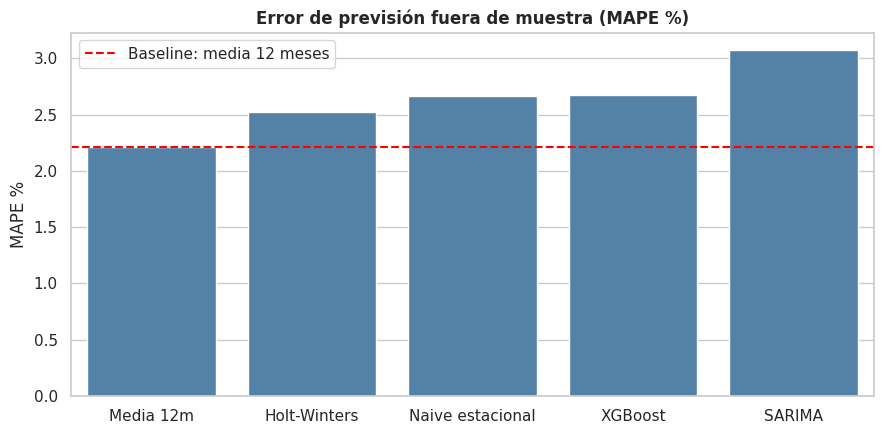

In [ ]:
H = 3   # horizonte de previsión (meses)

def prever(nombre, y_tr, h=H):
    """Previsión de h meses con datos hasta el final de y_tr (serie de unidades/día)."""
    if nombre == 'Media 12m':
        return np.repeat(y_tr.iloc[-12:].mean(), h)
    if nombre == 'Naive estacional':
        return y_tr.iloc[-12:].values[:h]                       # mismo mes del año anterior
    if nombre == 'Holt-Winters':
        m = ExponentialSmoothing(y_tr, trend='add', seasonal='add', seasonal_periods=12,
                                 damped_trend=True).fit()
        return np.asarray(m.forecast(h))
    if nombre == 'SARIMA':
        m = SARIMAX(y_tr, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        return np.asarray(m.forecast(h))
    if nombre == 'XGBoost':
        d = pd.DataFrame({'y': y_tr.values}, index=y_tr.index)
        d['mes'] = d.index.month
        d['lag12'] = d['y'].shift(12)
        d = d.dropna()
        m = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
        m.fit(d[['mes', 'lag12']], d['y'])
        idx_f = pd.date_range(y_tr.index[-1] + pd.offsets.MonthEnd(1), periods=h, freq='ME')
        Xf = pd.DataFrame({'mes': idx_f.month, 'lag12': y_tr.iloc[-12:].values[:h]})
        return m.predict(Xf)
    raise ValueError(nombre)

METODOS = ['Media 12m', 'Naive estacional', 'Holt-Winters', 'SARIMA', 'XGBoost']
n = len(serie_dia)
filas = []
for o in range(n - H - 12, n - H + 1):            # 13 orígenes, entrenamiento expansivo
    y_tr, y_real = serie_dia.iloc[:o], serie_dia.iloc[o:o + H]
    for met in METODOS:
        pred = prever(met, y_tr)
        ape = np.abs((y_real.values - pred) / y_real.values) * 100
        for k in range(H):
            filas.append({'Metodo': met, 'Origen': y_tr.index[-1], 'h': k + 1, 'APE': ape[k]})
bt = pd.DataFrame(filas)

tabla_bt = bt.groupby('Metodo')['APE'].agg(MAPE='mean', p90=lambda s: s.quantile(0.9)).sort_values('MAPE')
mape_base = tabla_bt.loc['Media 12m', 'MAPE']
tabla_bt['Mejora_vs_media_%'] = (1 - tabla_bt['MAPE'] / mape_base) * 100
print('Backtesting (13 orígenes x 3 meses) — error fuera de muestra:')
print(tabla_bt.round(2))

plt.figure(figsize=(9, 4.5))
sns.barplot(x=tabla_bt.index, y=tabla_bt['MAPE'], color='steelblue')
plt.axhline(mape_base, color='red', ls='--', label='Baseline: media 12 meses')
plt.title('Error de previsión fuera de muestra (MAPE %)', fontweight='bold')
plt.ylabel('MAPE %'); plt.xlabel(''); plt.legend(); plt.tight_layout(); plt.show()

Modelo elegido: Media 12m (MAPE = 2.2%; mejora vs media 12m = 0.0%)
Rango = previsión ± percentil 90 del error del backtesting
         Unidades_previstas  Minimo  Maximo
2025-01              5075.0  4832.0  5317.0
2025-02              4583.0  4364.0  4802.0
2025-03              5075.0  4832.0  5317.0


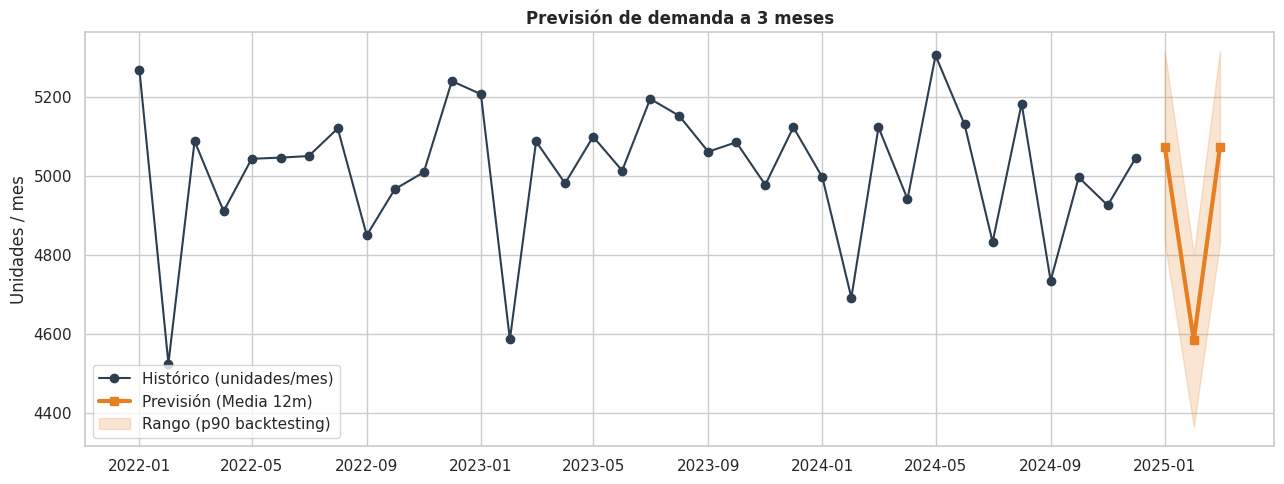

In [ ]:
# Previsión final con el modelo de menor error en el backtesting
mejor = tabla_bt.index[0]
mape_mejor = tabla_bt.loc[mejor, 'MAPE']
mejora_mejor = tabla_bt.loc[mejor, 'Mejora_vs_media_%']

prev_dia = prever(mejor, serie_dia)
idx_f = pd.date_range(serie_dia.index[-1] + pd.offsets.MonthEnd(1), periods=H, freq='ME')
prev_unid = prev_dia * np.asarray(idx_f.days_in_month)
p90 = tabla_bt.loc[mejor, 'p90']

prevision = pd.DataFrame({'Unidades_previstas': prev_unid.round(0),
                          'Minimo': (prev_unid * (1 - p90 / 100)).round(0),
                          'Maximo': (prev_unid * (1 + p90 / 100)).round(0)},
                         index=idx_f.strftime('%Y-%m'))
print(f'Modelo elegido: {mejor} (MAPE = {mape_mejor:.1f}%; mejora vs media 12m = {mejora_mejor:.1f}%)')
print('Rango = previsión ± percentil 90 del error del backtesting')
print(prevision)

hist = (serie_dia * serie_dia.index.days_in_month).iloc[-36:]      # unidades/mes equivalentes
x_hist = hist.index.to_period('M').to_timestamp()
x_prev = idx_f.to_period('M').to_timestamp()
plt.figure(figsize=(13, 5))
plt.plot(x_hist, hist.values, marker='o', color='#2c3e50', label='Histórico (unidades/mes)')
plt.plot(x_prev, prev_unid, marker='s', color='#e67e22', lw=3, label=f'Previsión ({mejor})')
plt.fill_between(x_prev, prevision['Minimo'].values, prevision['Maximo'].values, color='#e67e22', alpha=0.2, label='Rango (p90 backtesting)')
plt.title('Previsión de demanda a 3 meses', fontweight='bold')
plt.ylabel('Unidades / mes'); plt.legend(); plt.tight_layout(); plt.show()

## 7. Predicción de abandono (churn) con fecha de corte

Problema de la versión anterior: el label (días desde la última compra) y las variables (acumuladas con todo el histórico) se solapaban en el tiempo.

Ahora:
- **Variables** calculadas solo con pedidos hasta `fecha_corte`.
- **Label** = el cliente no vuelve a comprar en los `VENTANA` días posteriores.
- Se compara contra el azar (AUC 0,5), contra la tasa base y contra la regla más simple (solo recencia).

In [ ]:
VENTANA = 150     # días sin comprar = abandono (regla de negocio)

# ¿Es coherente 150 días con el ritmo de recompra real?
ordenados = df.sort_values(['CustomerID', 'OrderDate'])
gaps = ordenados.groupby('CustomerID')['OrderDate'].diff().dt.days.dropna()
print('Días entre compras consecutivas del mismo cliente:')
print(gaps.describe(percentiles=[.25, .5, .75, .9]).round(0))
print(f"Clientes con un solo pedido: {(df.groupby('CustomerID').size() == 1).mean():.1%}")

def construir_churn(ventana):
    """Variables con pedidos hasta la fecha de corte; label = no compra en los `ventana` días siguientes."""
    fecha_corte = df['OrderDate'].max() - pd.Timedelta(days=ventana)
    pre = df[df['OrderDate'] <= fecha_corte]
    post = df[df['OrderDate'] > fecha_corte]
    cli = pre.groupby('CustomerID').agg(
        Ultima=('OrderDate', 'max'), Primera=('OrderDate', 'min'),
        Pedidos=('OrderID', 'count'), Gasto=('TotalAmount', 'sum'),
        Unidades=('Quantity', 'sum'), Desc_medio=('Discount', 'mean'),
        Ticket_medio=('TotalAmount', 'mean'), N_categorias=('Category', 'nunique'),
        Tasa_fallo=('Fallo', 'mean'))
    cli['Recencia'] = (fecha_corte - cli['Ultima']).dt.days
    cli['Antiguedad'] = (fecha_corte - cli['Primera']).dt.days
    cli['Churn'] = (~cli.index.isin(post['CustomerID'].unique())).astype(int)
    return cli.drop(columns=['Ultima', 'Primera']), fecha_corte

clientes, fecha_corte = construir_churn(VENTANA)
tasa_churn = clientes['Churn'].mean()
print(f'\nFecha de corte: {fecha_corte.date()} | clientes: {len(clientes):,} | tasa de abandono a {VENTANA} días: {tasa_churn:.1%}')

Días entre compras consecutivas del mismo cliente:
count    56767.0
mean       434.0
std        362.0
min          0.0
25%        145.0
50%        339.0
75%        636.0
90%        972.0
max       1819.0
Name: OrderDate, dtype: float64
Clientes con un solo pedido: 31.3%



Fecha de corte: 2024-08-01 | clientes: 42,039 | tasa de abandono a 150 días: 85.0%


In [ ]:
X_c = clientes.drop(columns='Churn')
y_c = clientes['Churn']
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_c, y_c, test_size=0.2, stratify=y_c, random_state=42)

logit = make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced', max_iter=1000))
logit.fit(Xc_tr, yc_tr)
p_logit = logit.predict_proba(Xc_te)[:, 1]

rf_cv = GridSearchCV(RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
                     {'max_depth': [4, 8], 'min_samples_leaf': [30, 60]},
                     cv=3, scoring='roc_auc', n_jobs=-1)
rf_cv.fit(Xc_tr, yc_tr)
p_rf = rf_cv.predict_proba(Xc_te)[:, 1]
print('Mejores hiperparámetros RF:', rf_cv.best_params_)

p_rec = Xc_te['Recencia'].values.astype(float)     # regla simple: más días sin comprar = más riesgo

def evaluar_churn(nombre, score):
    auc = roc_auc_score(yc_te, score)
    ap = average_precision_score(yc_te, score)
    k = int(len(yc_te) * 0.10)
    lift = yc_te.values[np.argsort(-score)[:k]].mean() / yc_te.mean()
    print(f'{nombre:<28} AUC = {auc:.3f} | AP = {ap:.3f} (base {yc_te.mean():.3f}) | Lift top 10% = {lift:.2f}')
    return auc

print('\nReferencia: azar -> AUC 0.500 | lift 1.00')
auc_logit = evaluar_churn('Regresión logística', p_logit)
auc_rf = evaluar_churn('Random Forest (CV)', p_rf)
auc_rec = evaluar_churn('Regla: solo recencia', p_rec)

print('\nRandom Forest — informe con umbral 0.5:')
print(classification_report(yc_te, (p_rf >= 0.5).astype(int), digits=3))

Mejores hiperparámetros RF: {'max_depth': 4, 'min_samples_leaf': 30}

Referencia: azar -> AUC 0.500 | lift 1.00
Regresión logística          AUC = 0.497 | AP = 0.849 (base 0.850) | Lift top 10% = 1.01
Random Forest (CV)           AUC = 0.492 | AP = 0.847 (base 0.850) | Lift top 10% = 1.00
Regla: solo recencia         AUC = 0.505 | AP = 0.852 (base 0.850) | Lift top 10% = 1.00

Random Forest — informe con umbral 0.5:
              precision    recall  f1-score   support

           0      0.145     0.376     0.209      1261
           1      0.847     0.607     0.707      7147

    accuracy                          0.573      8408
   macro avg      0.496     0.492     0.458      8408
weighted avg      0.741     0.573     0.633      8408



In [ ]:
# Sensibilidad: ¿cambia la conclusión si se cambia la ventana de abandono?
filas = []
for v in [90, 150, 270, 365]:
    cli, _ = construir_churn(v)
    Xs, ys = cli.drop(columns='Churn'), cli['Churn']
    a, b, c, d = train_test_split(Xs, ys, test_size=0.2, stratify=ys, random_state=42)
    m = make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced', max_iter=1000)).fit(a, c)
    filas.append({'Ventana_dias': v, 'Clientes': len(cli), 'Tasa_abandono_%': ys.mean() * 100,
                  'AUC_logistica': roc_auc_score(d, m.predict_proba(b)[:, 1]),
                  'AUC_recencia': roc_auc_score(d, b['Recencia'])})
sens_churn = pd.DataFrame(filas)
auc_sens_max = sens_churn[['AUC_logistica', 'AUC_recencia']].max().max()
print(sens_churn.round(3).to_string(index=False))

 Ventana_dias  Clientes  Tasa_abandono_%  AUC_logistica  AUC_recencia
           90     42544           90.788          0.519         0.528
          150     42039           85.002          0.497         0.505
          270     40942           74.547          0.504         0.497
          365     39961           67.155          0.496         0.493


## 8. Venta cruzada

Primero se comprueba la estructura de los datos: si cada pedido contiene un único producto, **no se pueden
estudiar cestas**. Alternativa: afinidad a nivel de **cliente** (productos que compra un mismo cliente),
medida con *lift* (1 = independencia).

In [ ]:
prod_por_pedido = df.groupby('OrderID')['ProductName'].nunique()
n_multiproducto = int((prod_por_pedido > 1).sum())
print(f'Pedidos con más de un producto: {n_multiproducto:,} de {len(prod_por_pedido):,}')

M = (pd.crosstab(df['CustomerID'], df['ProductName']) > 0).astype(int)
N_cli = len(M)
co = M.T.dot(M)
soporte = np.diag(co.values).copy()
lift = co.values * N_cli / np.outer(soporte, soporte)

prods = list(M.columns)
pares = []
for i in range(len(prods)):
    for j in range(i + 1, len(prods)):
        if co.values[i, j] >= 30:                      # soporte mínimo
            pares.append((prods[i], prods[j], int(co.values[i, j]), lift[i, j]))
pares = pd.DataFrame(pares, columns=['Producto_A', 'Producto_B', 'Clientes_ambos', 'Lift']).sort_values('Lift', ascending=False)

lift_max = pares['Lift'].max() if len(pares) else np.nan
print(f'Pares evaluados: {len(pares)} | Lift mínimo = {pares["Lift"].min():.2f} | máximo = {lift_max:.2f}')
print('\nTop 5 pares por lift:')
print(pares.head(5).round(2).to_string(index=False))

Pedidos con más de un producto: 0 de 100,000


Pares evaluados: 1225 | Lift mínimo = 0.60 | máximo = 1.15

Top 5 pares por lift:
       Producto_A                  Producto_B  Clientes_ambos  Lift
    Action Camera              Graphic Tablet             102  1.15
        Air Fryer Noise Cancelling Headphones             103  1.14
       Board Game            Smart Light Bulb             104  1.13
     Gaming Mouse               Puzzle 1000pc              99  1.13
Bluetooth Speaker                Fitness Band              93  1.12


## 9. Resumen automático para las conclusiones

Esta celda redacta cada resultado según los contrastes estadísticos, para no afirmar más de lo que muestran los datos.

In [ ]:
print('=' * 78)
print('RESUMEN AUTOMÁTICO')
print('=' * 78)

print('\n[1] Método de pago y devoluciones')
print('   ', 'Existen diferencias significativas entre métodos.' if p_pago < ALFA
      else f'Sin evidencia de relación (p = {p_pago:.3f}).')

print('\n[2] Descuentos')
print('   ', f'Unidades por pedido: {"cambian" if p_kw < ALFA else "sin cambios significativos"} '
      f'según el descuento (Kruskal p = {p_kw:.3f}; Spearman rho = {rho:.3f}).')
print('   ', f'Con el descuento máximo el ticket neto es {caida_ticket:.1f}% respecto a sin descuento; '
      f'las unidades suben {uplift_obs:.1f}% frente al {uplift_nec:.1f}% necesario para no perder ingreso.')
print('   ', f'Modelo de cantidad sin leakage: R² = {r2_ok:.3f} (baseline {r2_base:.3f}).')
print('   ', 'Recomendación: validar cualquier política de descuentos con un test A/B (sin costes no se puede medir margen).')

print('\n[3] Segmentos RFM')
for seg in ['VIP', 'Alto valor inactivo (win-back)']:
    if seg in res_rfm.index:
        print('   ', f'{seg}: {res_rfm.loc[seg, "%_Clientes"]:.1f}% de clientes y {res_rfm.loc[seg, "%_Ingresos"]:.1f}% del ingreso neto.')
top_seg = res_rfm['%_Ingresos'].idxmax()
print('   ', f'El segmento con más ingresos es "{top_seg}" ({res_rfm.loc[top_seg, "%_Ingresos"]:.1f}% del ingreso neto '
      f'con {res_rfm.loc[top_seg, "%_Clientes"]:.1f}% de clientes).')

print('\n[4] Fallos logísticos')
print('   ', f'Tasa global de fallo: {tasa_global:.2%}. Ingreso en riesgo: {ingreso_riesgo:,.0f} $ '
      f'({ingreso_riesgo / ingreso_bruto:.1%} del bruto). Coste de envío perdido: {coste_envio:,.0f} $ '
      f'({coste_envio / ingreso_bruto:.2%} del bruto).')
print('   ', (f'Hay {n_signif} vendedores significativamente peores que la media tras corregir comparaciones múltiples.'
      if n_signif > 0 else f'Ningún vendedor es significativamente peor que la media (p global = {p_vend:.3f}): '
      'las diferencias observadas son compatibles con el azar.'))

print('\n[5] Estacionalidad')
print('   ', f'Pedidos por mes vs días del mes: p = {p_mes:.3f}; rango del índice por día = {rango_estac:.1f} puntos '
      f'-> {"sin variación significativa" if p_mes >= ALFA else ("diferencia estadísticamente marginal y de magnitud pequeña" if rango_estac < 5 else "variación estacional relevante")}.')
print('   ', f'Mix de categorías por mes: {"depende del mes" if p_cat_mes < ALFA else "sin dependencia significativa"} '
      f'(p = {p_cat_mes:.3f}).')

print('\n[6] Tendencia y previsión')
print('   ', f'Tendencia lineal: {pct_anual:+.2f}% anual (p = {p_tend:.3f}) -> '
      f'{"significativa" if p_tend < ALFA else "no significativa"}.')
if mejor == 'Media 12m':
    print('   ', f'Ningún modelo supera a la media de los últimos 12 meses en backtesting (MAPE {mape_mejor:.1f}%): '
          'la demanda diaria es estable y no hay patrón que un modelo aproveche.')
else:
    print('   ', f'Mejor modelo en backtesting: {mejor} (MAPE {mape_mejor:.1f}%), '
          f'{"mejora" if mejora_mejor > 10 else "sin mejora relevante frente a"} la media de 12 meses ({mejora_mejor:.1f}%).')
print('   ', 'Previsión a 3 meses (unidades):', prevision['Unidades_previstas'].astype(int).tolist())

print('\n[7] Churn')
print('   ', f'Tasa de abandono a {VENTANA} días: {tasa_churn:.1%}. AUC: logística {auc_logit:.3f}, RF {auc_rf:.3f}, '
      f'solo recencia {auc_rec:.3f}.')
print('   ', f'Sensibilidad a la ventana (90-365 días): AUC máximo = {auc_sens_max:.3f}.')
mejor_auc = max(auc_logit, auc_rf, auc_sens_max)
if mejor_auc < 0.60:
    print('   ', 'Capacidad predictiva débil: no justifica campañas basadas en el modelo; usar reglas RFM.')
elif mejor_auc <= auc_rec + 0.02:
    print('   ', 'El modelo no mejora la regla de recencia: bastan reglas simples.')
else:
    print('   ', 'El modelo aporta valor sobre la regla simple: candidato a priorizar campañas de retención.')

print('\n[8] Venta cruzada')
print('   ', f'Pedidos multiproducto: {n_multiproducto}. Lift máximo entre productos a nivel cliente: {lift_max:.2f} '
      f'({"sin afinidades claras" if lift_max < 1.2 else "hay pares con afinidad a revisar"}).')

print('\nLimitaciones: sin costes/márgenes, sin visitas/conversión ni datos de competencia, una única fuente de datos.')

RESUMEN AUTOMÁTICO

[1] Método de pago y devoluciones
    Sin evidencia de relación (p = 0.800).

[2] Descuentos
    Unidades por pedido: sin cambios significativos según el descuento (Kruskal p = 0.759; Spearman rho = -0.002).
    Con el descuento máximo el ticket neto es -26.4% respecto a sin descuento; las unidades suben 1.4% frente al 42.9% necesario para no perder ingreso.
    Modelo de cantidad sin leakage: R² = -0.015 (baseline -0.000).
    Recomendación: validar cualquier política de descuentos con un test A/B (sin costes no se puede medir margen).

[3] Segmentos RFM
    VIP: 6.5% de clientes y 14.9% del ingreso neto.
    Alto valor inactivo (win-back): 6.5% de clientes y 11.1% del ingreso neto.
    El segmento con más ingresos es "Activos recurrentes" (53.0% del ingreso neto con 43.9% de clientes).

[4] Fallos logísticos
    Tasa global de fallo: 6.08%. Ingreso en riesgo: 5,631,785 $ (6.1% del bruto). Coste de envío perdido: 45,065 $ (0.05% del bruto).
    Ningún vendedor es s